# 🚗 PART B – Exploratory Data Analysis (EDA)
## Project: Second-Hand Car Price Estimation – Moteur.ma
**Course:** AI Algorithms and Predictions  
**Dataset:** `raw_moteur.csv`  
**Author:** [Your Name]  

---

## 📌 Project Description

The goal of this project is to build a data-driven tool that estimates the **fair price of a second-hand car** in Morocco, based on listings from [moteur.ma](https://www.moteur.ma).

## 🎯 My Role – EDA

EDA (Exploratory Data Analysis) is the **first analysis step** after data collection. My job is to:
- Understand the structure of the dataset
- Detect anomalies and missing values
- Visualize distributions and relationships between variables
- Extract useful insights to prepare for modeling

## 📋 Notebook Plan

| Step | Description |
|------|-------------|
| 1 | Import libraries |
| 2 | Load the dataset |
| 3 | General overview of the dataset |
| 4 | Missing values analysis |
| 5 | Descriptive statistics |
| 6 | Target variable analysis: Price |
| 7 | Categorical variables analysis |
| 8 | Numerical variables analysis |
| 9 | Correlation between variables |
| 10 | Outlier detection |
| 11 | Insights and conclusions |

---
## STEP 1 – Import Libraries

We import all the libraries we need for analysis and visualization.
- **pandas** : work with data tables
- **numpy** : math calculations
- **matplotlib / seaborn** : create charts and graphs
- **warnings** : hide unnecessary warning messages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


---
## STEP 2 – Load the Dataset

We load the CSV file provided by the person in charge of scraping (Part A).  
The file is called `raw_moteur.csv` and contains raw car listings from moteur.ma.

In [ ]:

df = pd.read_csv('../data/raw_moteur.csv')

print(f'✅ Dataset loaded successfully')
print(f'📊 Number of rows    : {df.shape[0]}')
print(f'📊 Number of columns : {df.shape[1]}')

✅ Dataset loaded successfully
📊 Number of rows    : 8184
📊 Number of columns : 22


---
## STEP 3 – General Overview of the Dataset

Before any analysis, we look at the first rows of the dataset to understand its structure:  
what columns exist, what types of data they contain, etc.

In [3]:
# Show the first 5 rows
print('🔍 First rows of the dataset:')
df.head()

🔍 First rows of the dataset:


,Lien_index,Marque,Modèle,Année,Kilométrage,Carburant,Transmission,Carrosserie,Couleur,Puissance fiscale,...,ville,État du véhicule,Airbags,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,Cylindrée
0,0,Skoda,Superb,2019.0,"107,000 km",Diesel,Automatique,NaN,NaN,NaN,...,Casablanca,1,0,0,0,0,0,0,0,NaN
1,1,Nissan,Qashqai,2013.0,"178,000 km",Diesel,Manuelle,SUV et 4x4,Noir,7.0,...,NaN,0,0,0,0,0,0,0,0,NaN
2,2,Volkswagen,Golf 5,2007.0,"249,000 km",Diesel,Manuelle,Coupé,Bleu marine,8.0,...,Casablanca,0,1,1,0,0,1,0,0,NaN
3,3,Peugeot,2008,2014.0,"168,000 km",Diesel,Manuelle,NaN,NaN,6.0,...,Tanger,0,0,0,0,0,0,0,0,NaN
4,4,Citroën,C5,2019.0,"129,000 km",Diesel,Automatique,NaN,NaN,8.0,...,Casablanca,0,0,0,0,0,0,0,0,NaN


In [4]:
# General info: column types and non-null counts
print('📋 General dataset info:')
df.info()

📋 General dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8184 entries, 0 to 8183
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lien_index           8184 non-null   int64  
 1   Marque               8152 non-null   object 
 2   Modèle               8152 non-null   object 
 3   Année                8141 non-null   float64
 4   Kilométrage          8152 non-null   object 
 5   Carburant            8139 non-null   object 
 6   Transmission         8094 non-null   object 
 7   Carrosserie          3320 non-null   object 
 8   Couleur              4591 non-null   object 
 9   Puissance fiscale    6322 non-null   float64
 10  Nombre de portes     5721 non-null   float64
 11  prix                 6966 non-null   float64
 12  ville                7493 non-null   object 
 13  État du véhicule     8184 non-null   int64  
 14  Airbags              8184 non-null   int64  
 15  Navigation GPS

In [5]:
# List all columns
print('📌 Available columns:')
print(df.columns.tolist())

📌 Available columns:
['Lien_index', 'Marque', 'Modèle', 'Année', 'Kilométrage', 'Carburant', 'Transmission', 'Carrosserie', 'Couleur', 'Puissance fiscale', 'Nombre de portes', 'prix', 'ville', 'État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'Cylindrée']


In [6]:
# Data type of each column
print('🔢 Data types:')
print(df.dtypes)

🔢 Data types:
Lien_index               int64
Marque                  object
Modèle                  object
Année                  float64
Kilométrage             object
Carburant               object
Transmission            object
Carrosserie             object
Couleur                 object
Puissance fiscale      float64
Nombre de portes       float64
prix                   float64
ville                   object
État du véhicule         int64
Airbags                  int64
Navigation GPS           int64
Ordinateur de bord       int64
Limiteur de vitesse      int64
Climatisation            int64
Intérieur cuir           int64
Radar de recul           int64
Cylindrée              float64
dtype: object


---
## STEP 4 – Missing Values Analysis

Missing values (NaN) can cause problems for machine learning models.  
Here we identify how many there are per column and their percentage.

In [7]:
# Count missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
}).sort_values('Percentage (%)', ascending=False)

print('❓ Missing values per column:')
print(missing_df[missing_df['Missing Values'] > 0])

❓ Missing values per column:
                   Missing Values  Percentage (%)
Cylindrée                    8182           99.98
Carrosserie                  4864           59.43
Couleur                      3593           43.90
Nombre de portes             2463           30.10
Puissance fiscale            1862           22.75
prix                         1218           14.88
ville                         691            8.44
Transmission                   90            1.10
Carburant                      45            0.55
Année                          43            0.53
Marque                         32            0.39
Kilométrage                    32            0.39
Modèle                         32            0.39


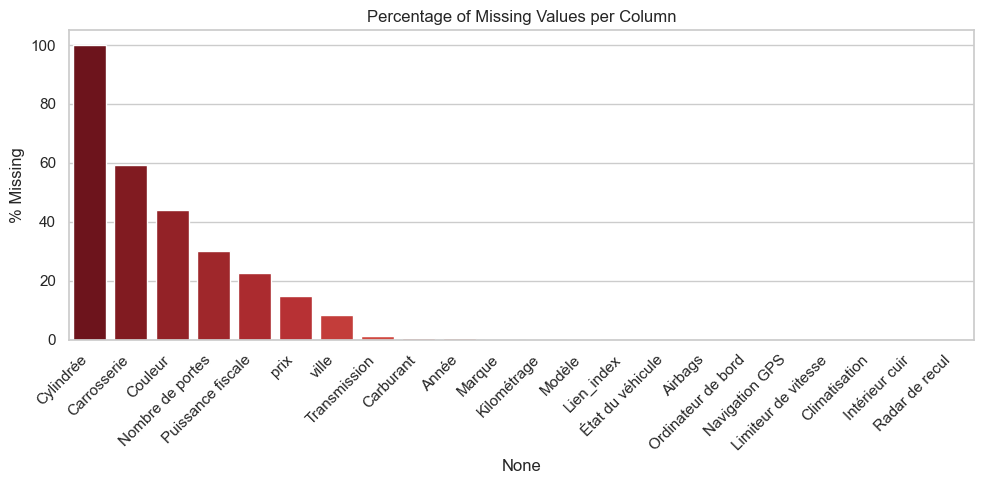

In [8]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()

---
## STEP 5 – Descriptive Statistics

We calculate basic statistics (mean, min, max, standard deviation, quartiles) for numerical columns.  
This gives us a first idea of how the data is distributed.

In [9]:
# Statistics for numerical variables
print('📊 Descriptive statistics (numerical variables):')
df.describe().T

📊 Descriptive statistics (numerical variables):


,count,mean,std,min,25%,50%,75%,max
Lien_index,8184.0,4096.707234,2.364452e+03,0.0,2050.75,4096.5,6142.25,8199.0
Année,8141.0,2004.648323,1.669542e+02,0.0,2016.00,2020.0,2022.00,2026.0
Puissance fiscale,6322.0,8.422493,3.816726e+00,2.0,6.00,8.0,9.00,55.0
Nombre de portes,5721.0,4.788324,5.423756e-01,3.0,5.00,5.0,5.00,5.0
prix,6966.0,284423.844100,1.131660e+06,1.0,135000.00,200000.0,295000.00,58000000.0
État du véhicule,8184.0,0.284580,4.512416e-01,0.0,0.00,0.0,1.00,1.0
Airbags,8184.0,0.575024,4.943695e-01,0.0,0.00,1.0,1.00,1.0
Navigation GPS,8184.0,0.436217,4.959453e-01,0.0,0.00,0.0,1.00,1.0
Ordinateur de bord,8184.0,0.470797,4.991769e-01,0.0,0.00,0.0,1.00,1.0
Limiteur de vitesse,8184.0,0.492058,4.999675e-01,0.0,0.00,0.0,1.00,1.0


In [10]:
# Statistics for categorical variables
print('📊 Descriptive statistics (categorical variables):')
df.describe(include='object').T

📊 Descriptive statistics (categorical variables):


,count,unique,top,freq
Marque,8152,73,Mercedes-Benz,800
Modèle,8152,469,Autre,249
Kilométrage,8152,2129,0 km,467
Carburant,8139,4,Diesel,6263
Transmission,8094,3,Automatique,5331
Carrosserie,3320,14,SUV et 4x4,1142
Couleur,4591,27,Noir,1533
ville,7493,20,Casablanca,4160


---
## STEP 6 – Target Variable Analysis: Price

The **price** is our target variable (what we want to predict).  
We analyze its distribution: is it normal? skewed? Are there strange prices?

In [ ]:
price_col = 'prix'  

print('💰 Price statistics:')
print(df[price_col].describe())
print(f'\nMedian : {df[price_col].median():,.0f} MAD')
print(f'Skewness : {df[price_col].skew():.2f}')

💰 Price statistics:
count    6.966000e+03
mean     2.844238e+05
std      1.131660e+06
min      1.000000e+00
25%      1.350000e+05
50%      2.000000e+05
75%      2.950000e+05
max      5.800000e+07
Name: prix, dtype: float64

Median : 200,000 MAD
Skewness : 35.75


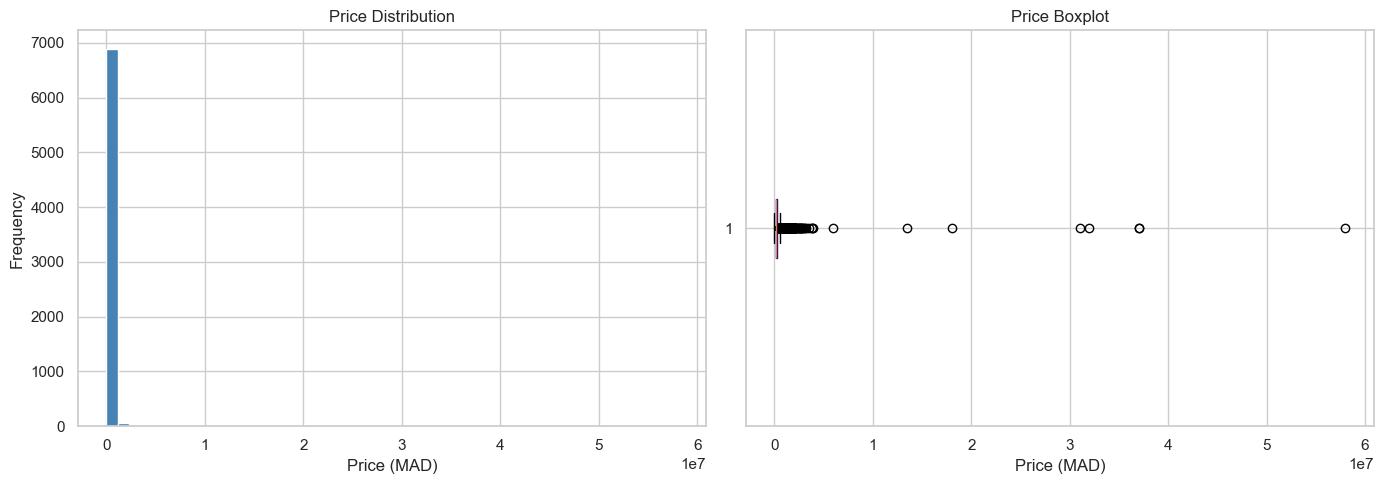

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[price_col].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (MAD)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df[price_col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Price Boxplot')
axes[1].set_xlabel('Price (MAD)')

plt.tight_layout()
plt.show()

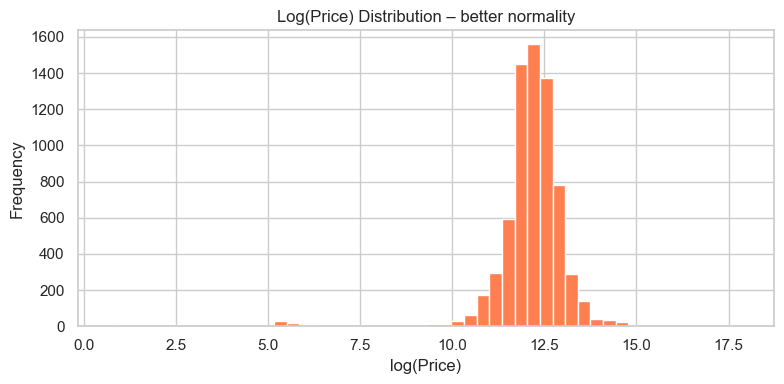

In [15]:
# Log of price distribution (useful when price is very skewed)
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df[price_col].dropna()), bins=50, color='coral', edgecolor='white')
plt.title('Log(Price) Distribution – better normality')
plt.xlabel('log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## STEP 7 – Categorical Variables Analysis

Categorical variables are: **brand, model, fuel type, transmission, city, condition**.  
We analyze their frequency to see which category dominates the market.

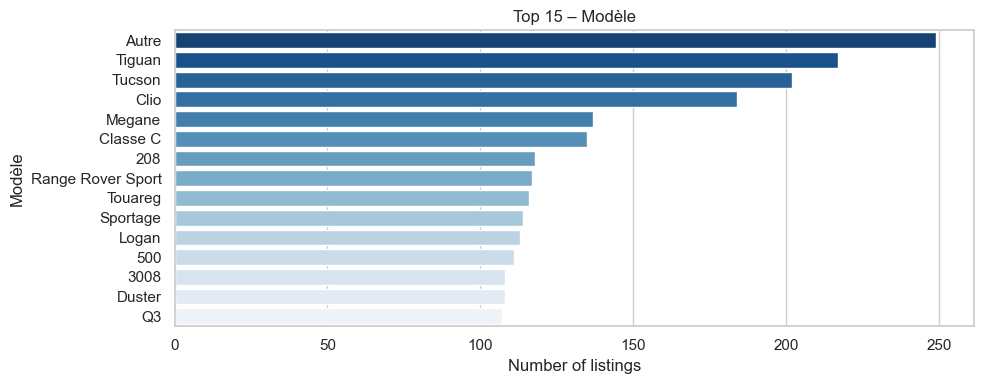


📌 Modèle: 469 unique categories



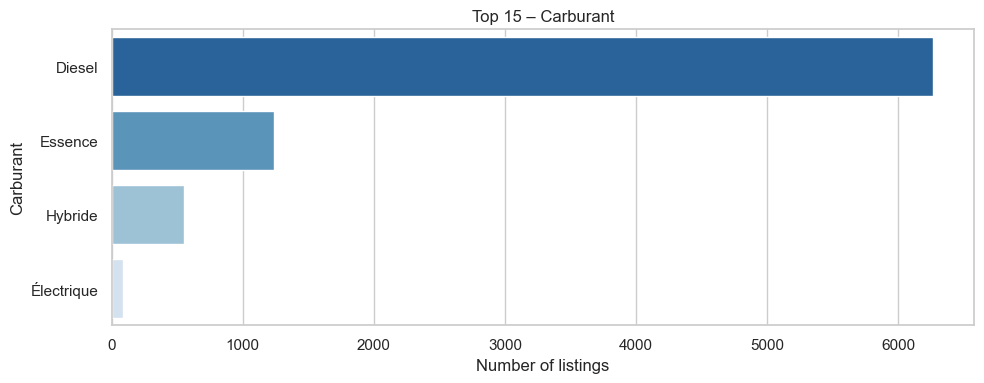


📌 Carburant: 4 unique categories



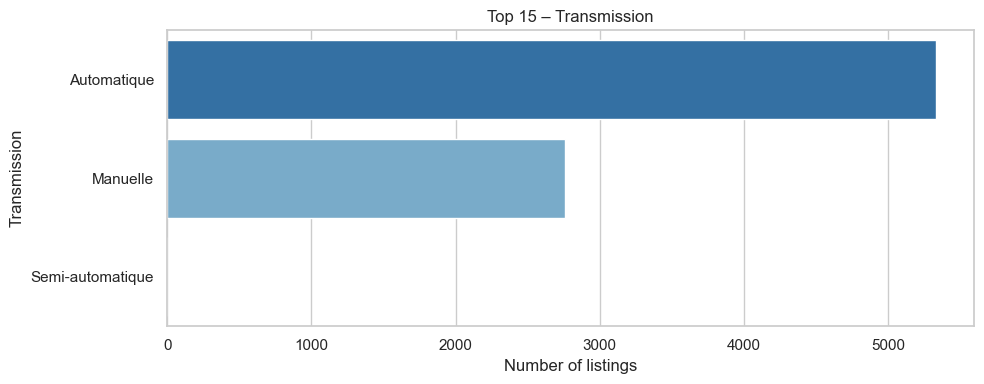


📌 Transmission: 3 unique categories



In [38]:
cat_cols = ['Modèle', 'Carburant', 'Transmission', 'Ville'] 

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        counts = df[col].value_counts().head(15)
        sns.barplot(x=counts.values, y=counts.index, palette='Blues_r')
        plt.title(f'Top 15 – {col}')
        plt.xlabel('Number of listings')
        plt.tight_layout()
        plt.show()
        print(f'\n📌 {col}: {df[col].nunique()} unique categories\n')

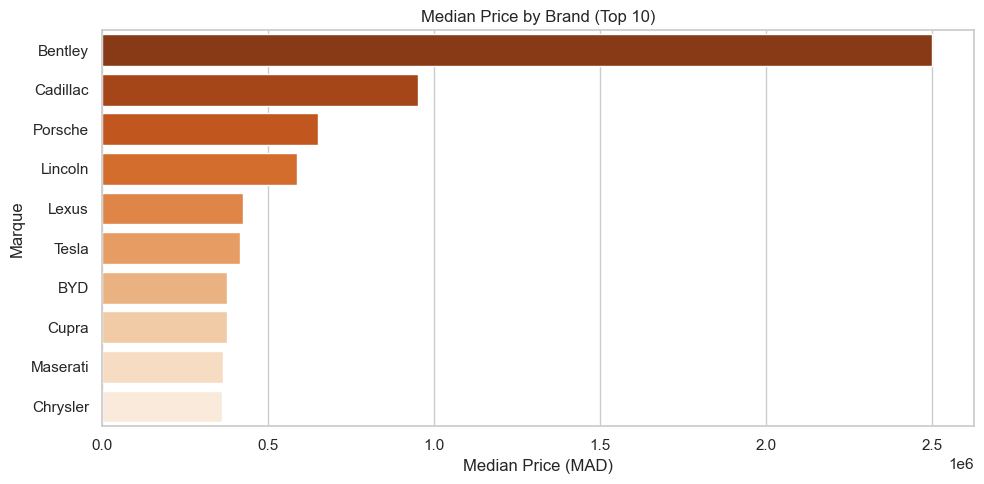

In [41]:
# Median price per brand (top 10)
if 'Marque' in df.columns and price_col in df.columns:
    price_by_brand = df.groupby('Marque')[price_col].median().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=price_by_brand.values, y=price_by_brand.index, palette='Oranges_r')
    plt.title('Median Price by Brand (Top 10)')
    plt.xlabel('Median Price (MAD)')
    plt.tight_layout()
    plt.show()

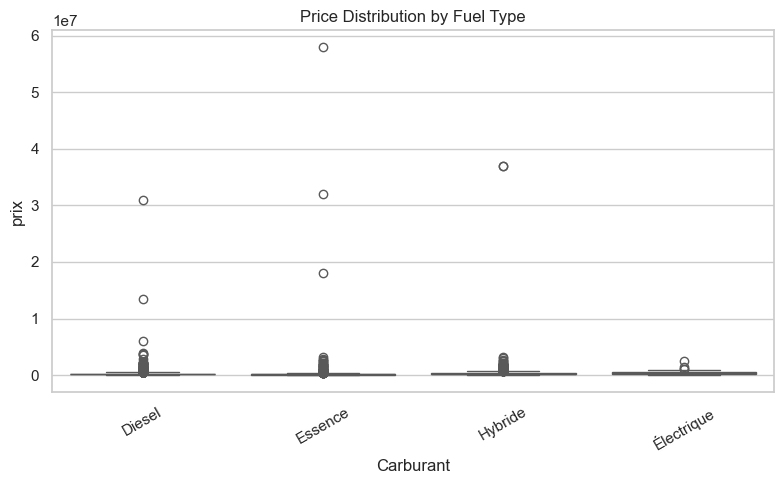

In [42]:
# Price by fuel type
if 'Carburant' in df.columns and price_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Carburant', y=price_col, palette='Set2')
    plt.title('Price Distribution by Fuel Type')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

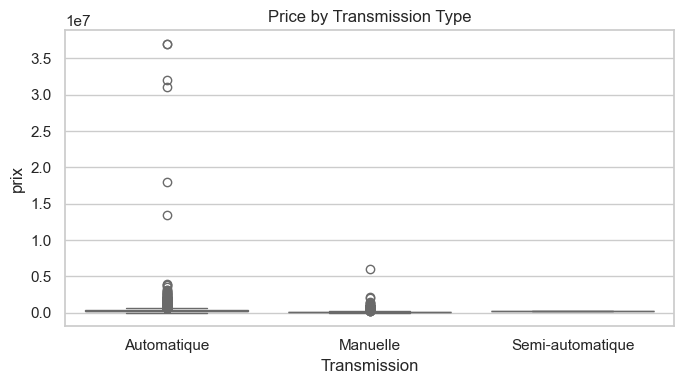

In [43]:
# Price by transmission type
if 'Transmission' in df.columns and price_col in df.columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='Transmission', y=price_col, palette='Set3')
    plt.title('Price by Transmission Type')
    plt.tight_layout()
    plt.show()

---
## STEP 8 – Numerical Variables Analysis

Important numerical variables are: **year, mileage, engine power**.  
We analyze their distribution and their relationship with price.

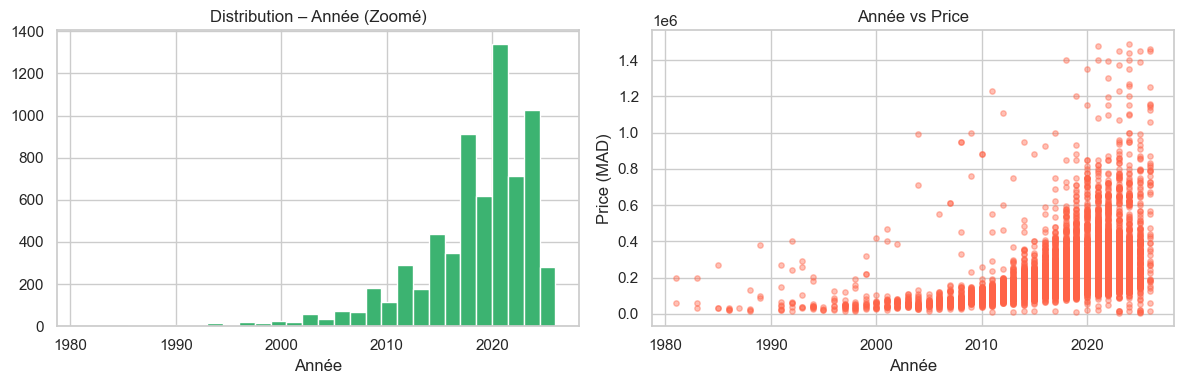

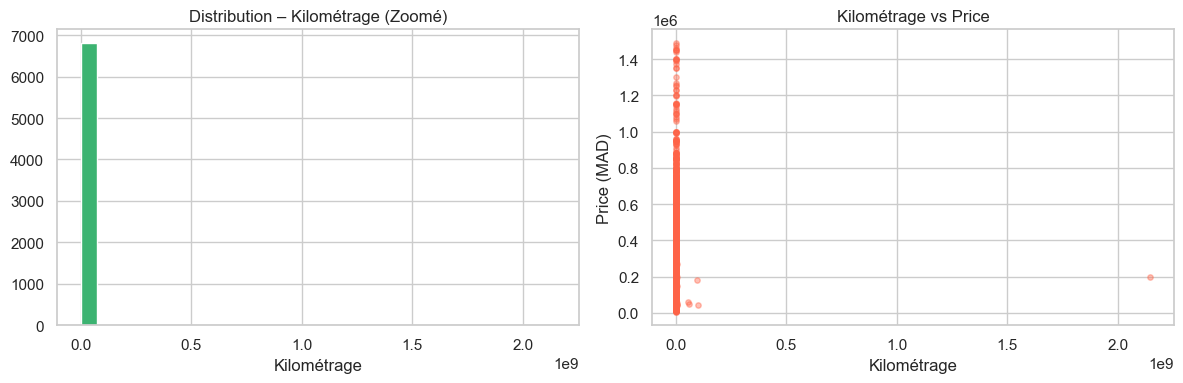

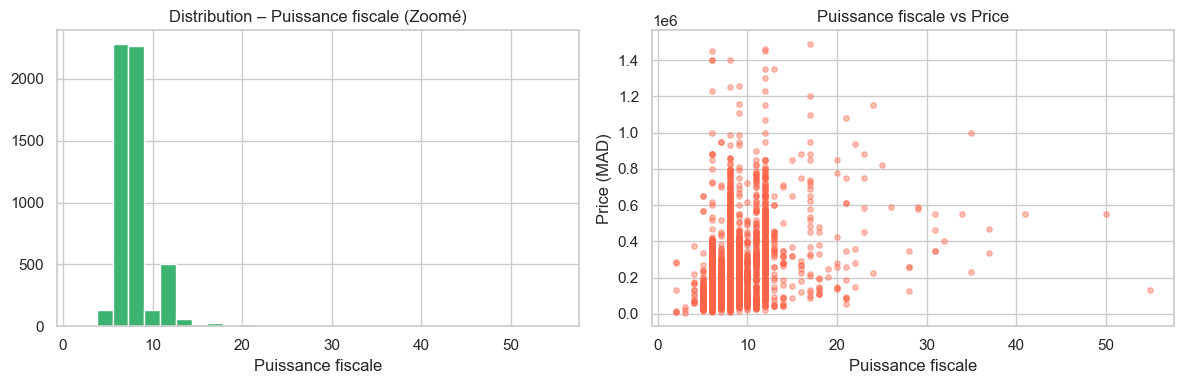

In [44]:
num_cols = ['Année', 'Kilométrage', 'Puissance fiscale']  

# 1. Nettoyage temporaire du Kilométrage s'il contient des chaînes de caractères (ex: "km", espaces)
# On enlève tout ce qui n'est pas un chiffre avant de convertir
if 'Kilométrage' in df.columns:
    df['Kilométrage_clean'] = df['Kilométrage'].astype(str).str.replace(r'[^0-9]', '', regex=True)
    df['Kilométrage_clean'] = pd.to_numeric(df['Kilométrage_clean'], errors='coerce')
else:
    df['Kilométrage_clean'] = pd.to_numeric(df[col], errors='coerce')

# 2. Conversion propre du Prix
clean_price = pd.to_numeric(df[price_col], errors='coerce')

# 3. Filtrage des Outliers extrêmes uniquement pour tes graphiques
# On ignore les prix aberrants (ex: > 1 500 000 MAD) et les années égales à 0
valid_data = df.copy()
valid_data['Price_clean'] = clean_price
valid_data['Année_clean'] = pd.to_numeric(df['Année'], errors='coerce')
valid_data['Puissance_clean'] = pd.to_numeric(df['Puissance fiscale'], errors='coerce')

# Filtre : On garde les prix raisonnables et les années logiques pour zoomer sur le graphique
graph_df = valid_data[(valid_data['Price_clean'] > 5000) & (valid_data['Price_clean'] < 1500000) & (valid_data['Année_clean'] > 1980)]

# Boucle d'affichage mise à jour
mapping_cols = {
    'Année': 'Année_clean',
    'Kilométrage': 'Kilométrage_clean',
    'Puissance fiscale': 'Puissance_clean'
}

for original_col, clean_col_name in mapping_cols.items():
    if original_col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Données sans NaN pour l'histogramme
        hist_data = graph_df[clean_col_name].dropna()
        
        # Histogram
        axes[0].hist(hist_data, bins=30, color='mediumseagreen', edgecolor='white')
        axes[0].set_title(f'Distribution – {original_col} (Zoomé)')
        axes[0].set_xlabel(original_col)
        
        # Scatter plot vs price
        axes[1].scatter(graph_df[clean_col_name], graph_df['Price_clean'], alpha=0.4, color='tomato', s=15)
        axes[1].set_title(f'{original_col} vs Price')
        axes[1].set_xlabel(original_col)
        axes[1].set_ylabel('Price (MAD)')
        
        plt.tight_layout()
        plt.show()

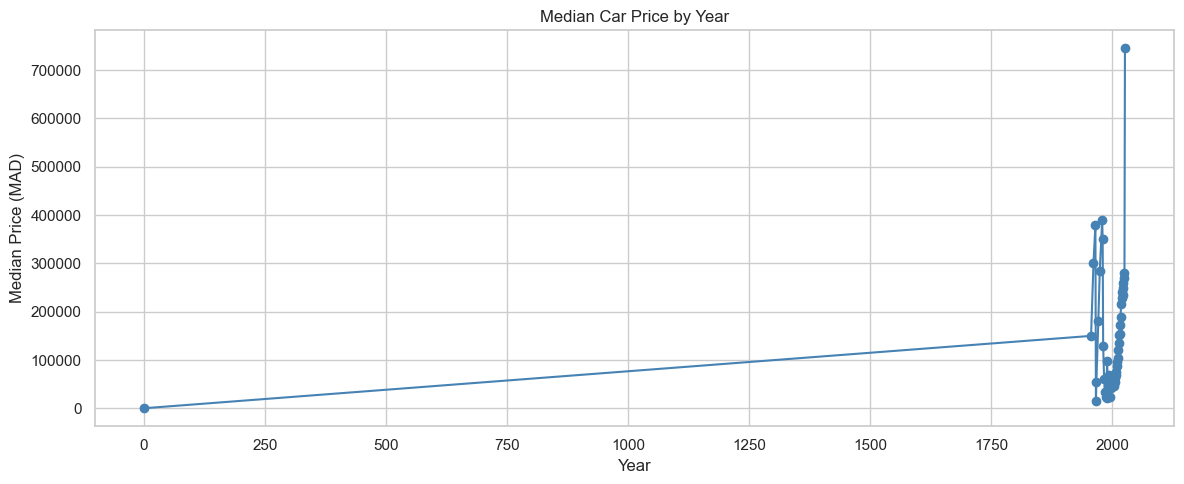

In [45]:
# Average price evolution by year
if 'Année' in df.columns and price_col in df.columns:
    price_by_year = df.groupby('Année')[price_col].median().reset_index()
    plt.figure(figsize=(12, 5))
    plt.plot(price_by_year['Année'], price_by_year[price_col], marker='o', color='steelblue')
    plt.title('Median Car Price by Year')
    plt.xlabel('Year')
    plt.ylabel('Median Price (MAD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

---
## STEP 9 – Correlation Between Variables

The correlation matrix shows how much two numerical variables move together.  
- Correlation close to **+1** = positive relationship (both go up together)
- Correlation close to **-1** = negative relationship (one goes up, the other goes down)
- Correlation close to **0** = no relationship

This is very important to know which variables influence the price the most.

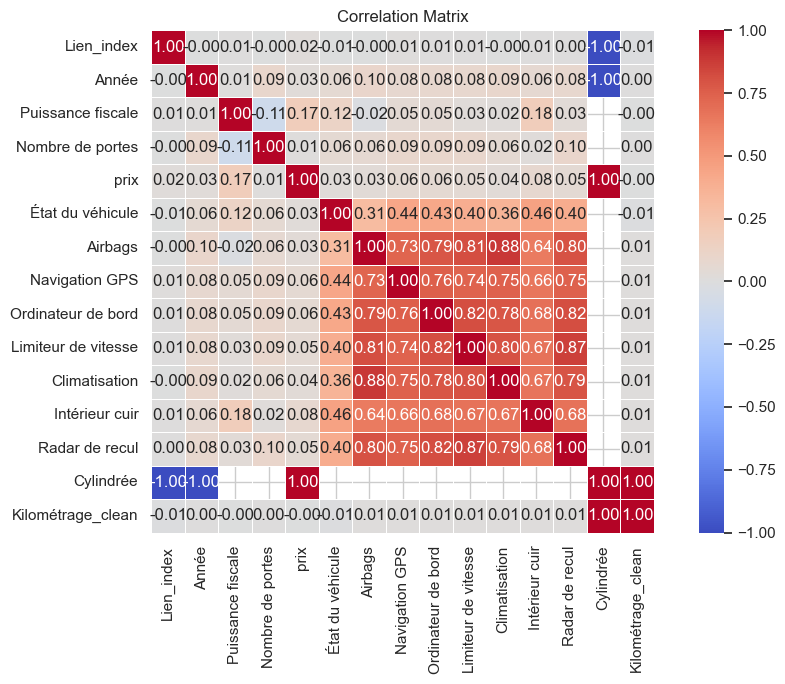

In [46]:
# Select only numerical columns
df_num = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
corr = df_num.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

📊 Correlation with Price:
Cylindrée              1.000000
Puissance fiscale      0.172758
Intérieur cuir         0.075966
Navigation GPS         0.061200
Ordinateur de bord     0.055087
Radar de recul         0.052045
Limiteur de vitesse    0.050275
Climatisation          0.038754
Airbags                0.031304
État du véhicule       0.030141
Année                  0.025233
Lien_index             0.015920
Nombre de portes       0.012961
Kilométrage_clean     -0.001440
Name: prix, dtype: float64


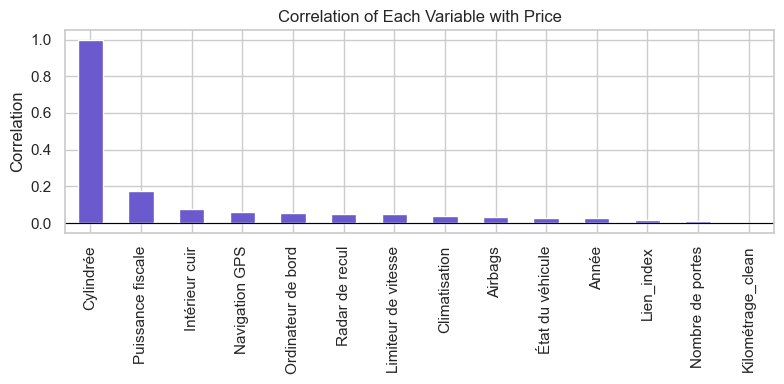

In [47]:
# Correlation of each variable with Price (ranked)
if price_col in df_num.columns:
    corr_price = corr[price_col].drop(price_col).sort_values(ascending=False)
    print('📊 Correlation with Price:')
    print(corr_price)

    plt.figure(figsize=(8, 4))
    corr_price.plot(kind='bar', color='slateblue')
    plt.title('Correlation of Each Variable with Price')
    plt.ylabel('Correlation')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

---
## STEP 10 – Outlier Detection

**Outliers** are extreme abnormal values (e.g. a car listed at 1 MAD or 50 million MAD).  
We detect them using the **IQR method** (Interquartile Range):
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 – Q1
- A value is an outlier if it is below Q1 – 1.5×IQR  or  above Q3 + 1.5×IQR

In [48]:
def detect_outliers_iqr(series, col_name):
    numeric_series = pd.to_numeric(series, errors='coerce').dropna()
    
    if len(numeric_series) == 0:
        print(f'⚠️ {col_name} : Impossible de calculer les outliers (la colonne ne contient que du texte non nettoyé)\n')
        return None, None
        
    Q1 = numeric_series.quantile(0.25)
    Q3 = numeric_series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = numeric_series[(numeric_series < lower) | (numeric_series > upper)]
    
    print(f'🔴 {col_name} : {len(outliers)} outliers détectés ({len(outliers)/len(numeric_series)*100:.1f}%)')
    print(f'   Lower bound: {lower:,.0f} | Upper bound: {upper:,.0f}\n')
    return lower, upper

for col in num_cols + [price_col]:
    if col in df.columns:
        detect_outliers_iqr(df[col], col)

🔴 Année : 380 outliers détectés (4.7%)
   Lower bound: 2,007 | Upper bound: 2,031

⚠️ Kilométrage : Impossible de calculer les outliers (la colonne ne contient que du texte non nettoyé)

🔴 Puissance fiscale : 321 outliers détectés (5.1%)
   Lower bound: 2 | Upper bound: 14

🔴 prix : 429 outliers détectés (6.2%)
   Lower bound: -105,000 | Upper bound: 535,000



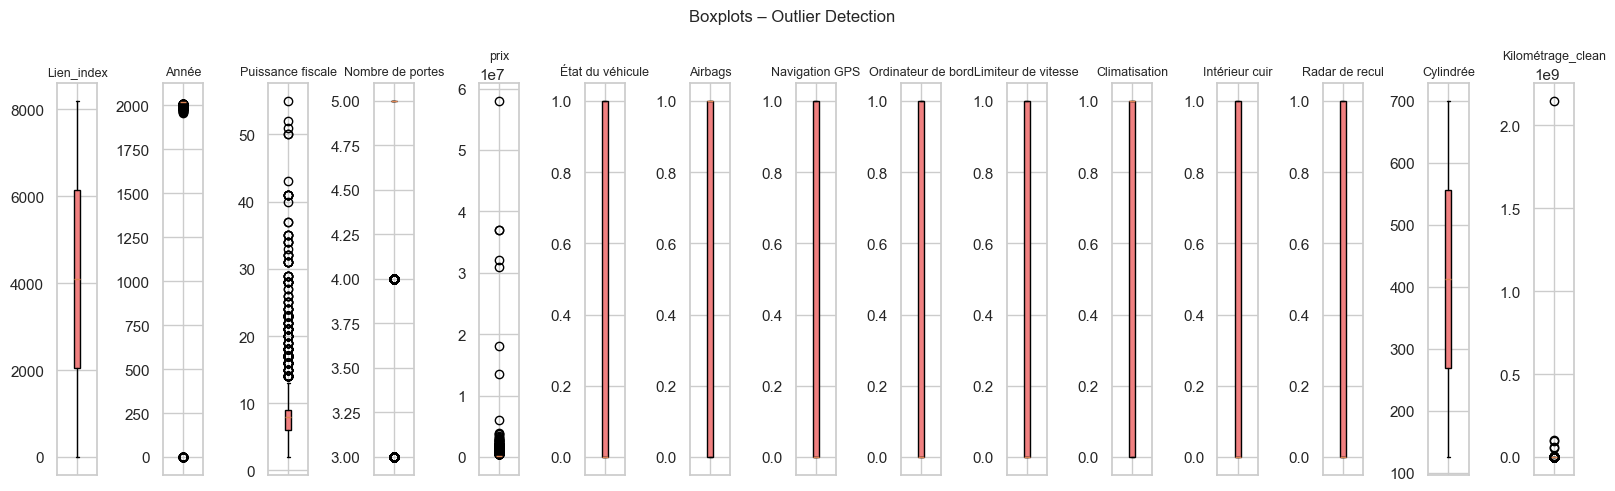

In [49]:
# Boxplots for all numerical variables
fig, axes = plt.subplots(1, len(df_num.columns), figsize=(16, 5))
for i, col in enumerate(df_num.columns):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral'))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Boxplots – Outlier Detection', fontsize=12)
plt.tight_layout()
plt.show()

---
## STEP 11 – Insights and Conclusions

This section summarizes the key observations from the EDA.  
These insights will be useful for the modeling team (Part D) and business insights (Part F).

> ✏️ **Fill this in after running all the cells above and reading the results**

### 📌 Summary of Observations

| Observation | Detail |
|-------------|--------|
| Dataset size | ... rows × ... columns |
| Missing values | Affected columns: ... |
| Price distribution | Skewed / Normal – median ≈ ... MAD |
| Most common brand | ... |
| Dominant fuel type | ... |
| Variable most correlated with price | ... (correlation = ...) |
| Outliers detected | ... in the price column |


### 📌 Business Insights

- **Newer cars** (after ...) have a significantly higher median price
- Mileage has a **negative correlation** with price: the more a car has been driven, the less it is worth
- **Automatic** cars are generally more expensive than manual ones
- Brand strongly influences price: premium brands (...) have prices well above average